In [1]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
# Step 2: Load the Dataset
df = pd.read_csv('Housing.csv')

In [3]:
#Step 3: Display first few rows
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
# Step 4: Check data information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None


In [5]:
# Step 5: Generate descriptive statistics
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


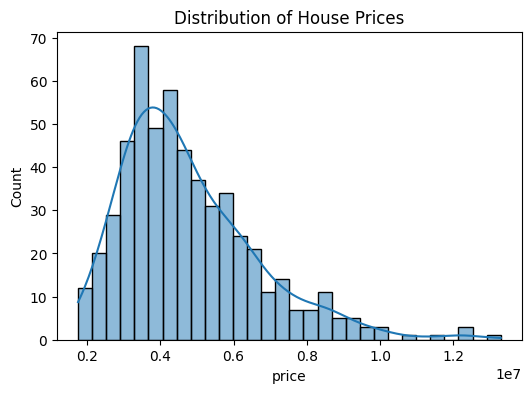

In [6]:
# Step 6: Visualize price distribution
# Create a histogram with KDE to understand the distribution of house prices
plt.figure(figsize=(6,4))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.show()

In [7]:
# Step 7: Separate numerical and categorical columns
# Identify and classify columns into numerical and categorical data types for preprocessing
num_col = []
cat_col = []
for i in df.columns:
    if df[i].dtypes=="O":
        cat_col.append(i)
    else:
        num_col.append(i)

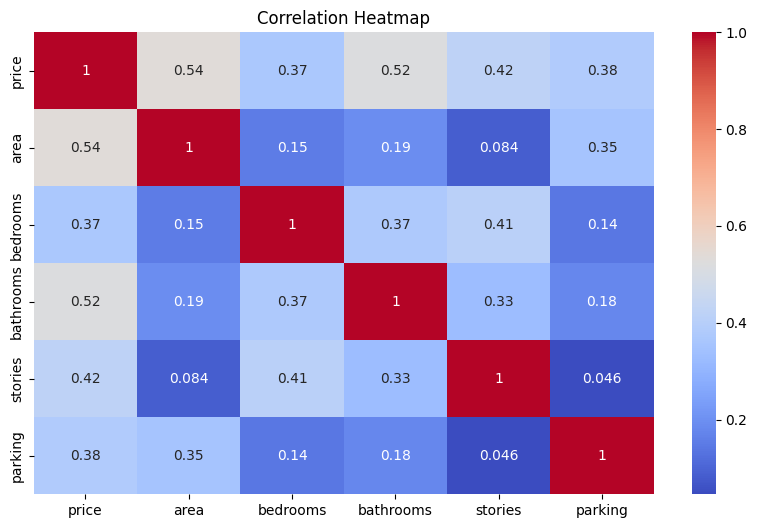

In [8]:
# Step 8: Analyze correlations
# Create a correlation heatmap to identify relationships between numerical features
plt.figure(figsize=(10,6))
sns.heatmap(df[num_col].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [9]:
# Step 9: Encode categorical variables
# Convert categorical variables into numerical format using one-hot encoding

df_encoded = pd.get_dummies(df, drop_first=True,dtype=int)  #drop_first=True Removes the first category from each categorical variable

In [10]:
# Step 10: Display encoded dataset
# View the transformed dataset with encoded categorical variables
df_encoded

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2,1,0,1,0,0,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,0,1,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


In [11]:
# Step 11: Separate features and target variable
# Split data into independent features (X) and dependent variable (y - price)
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

In [12]:
# Step 12: Standardize features
# Scale all features to have mean=0 and std=1 for better model performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)   #standardizes the feature values so all variables are on the same scale, which helps machine learning models perform better.

In [13]:
# Step 13: Split data into training and testing sets
# Divide the dataset into 80% training and 20% testing with random seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [14]:
# Step 14: Train Linear Regression model
# Fit the linear regression model using training data
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
# Step 15: Display model coefficients
# Show the intercept and coefficients for each feature in the linear equation
print("\nIntercept (β₀):", lr.intercept_)

coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient (βᵢ)": lr.coef_
})
display("Coefficient", coeff_df)



Intercept (β₀): 4737518.175380117


'Coefficient'

,Feature,Coefficient (βᵢ)
0,area,511615.563777
1,bedrooms,56615.572458
2,bathrooms,549420.501241
3,stories,353158.429856
4,parking,193542.781675
5,mainroad_yes,128151.921295
6,guestroom_yes,88590.213462
7,basement_yes,186194.150506
8,hotwaterheating_yes,143233.206250
9,airconditioning_yes,367817.894916


In [ ]:
# Step 16: Make predictions
# Use the trained model to predict house prices on the test set
y_pred = lr.predict(X_test)

In [ ]:
# Step 17: Evaluate model performance
# Calculate R² Score, MAE, and RMSE to assess model accuracy and error metrics
print("\nR² Score:", r2_score(y_test, y_pred)) 
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))



R² Score: 0.6529242642153175
MAE: 970043.4039201641
RMSE: 1324506.9600914405


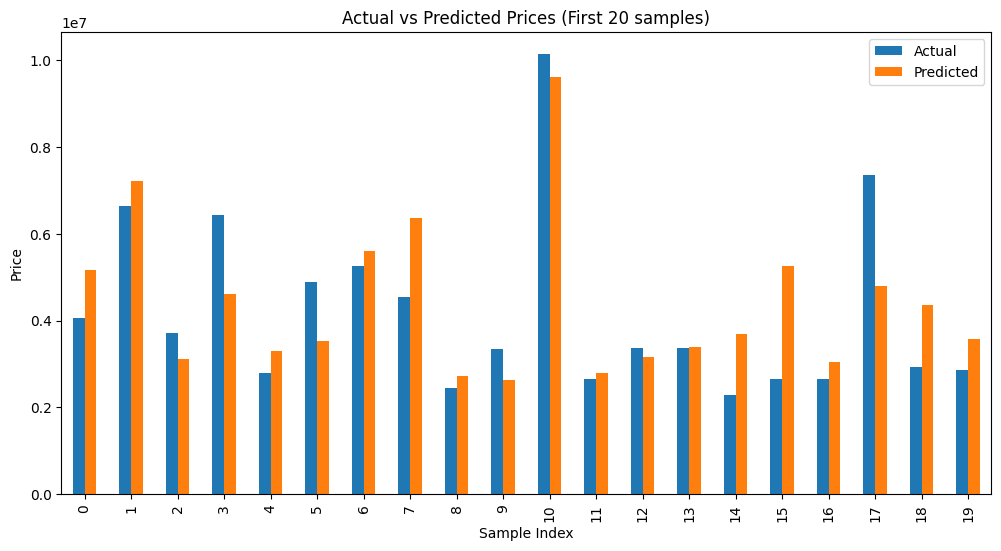

In [ ]:
# Step 18: Compare actual vs predicted prices (bar chart)
# Create a bar chart showing the first 20 samples of actual vs predicted values
comparison = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted": y_pred[:20]
})

comparison.plot(kind="bar", figsize=(12,6))
plt.title("Actual vs Predicted Prices (First 20 samples)")
plt.xlabel("Sample Index")
plt.ylabel("Price")
plt.show()

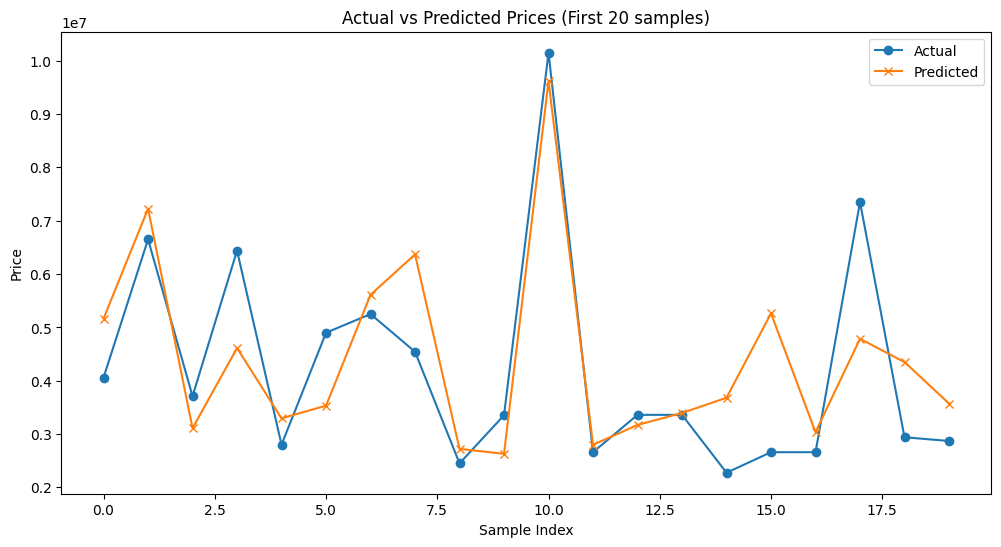

In [ ]:

# Step 19: Compare actual vs predicted prices (line chart)
# Create a line chart with markers to better visualize the comparison between actual and predicted values
plt.figure(figsize=(12,6))
plt.plot(range(20), y_test.values[:20], marker='o', label='Actual')
plt.plot(range(20), y_pred[:20], marker='x', label='Predicted')
plt.title("Actual vs Predicted Prices (First 20 samples)")
plt.xlabel("Sample Index")
plt.ylabel("Price")
plt.legend()
plt.show()
